# Data Mining Assignment 4 - Izaak King, kingi@rpi.edu
Attached is my submission for assignment 4.

## Data preparation

We first parse our given Breast Cancer Wisconsin (Diagnostic) dataset into a data matrix. ID variable isn't used, and Diagnosis variable will be used later to determine the ground truth clustering. The remaining data matrix, 569 x 30 will be scaled with sklearn's MinMaxScalar.

In [4]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from scipy.stats import multivariate_normal
from sklearn.metrics import normalized_mutual_info_score
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix


rawData = pd.read_csv("wdbc.data")          # Use Pandas Library to parse inital data file, store in Data frame
diagnosisData = (rawData.iloc[ : , 1]).to_numpy()          #The Second column is the Diagosis Variable
dataMatrix = (rawData.iloc[ : , 2: ]).to_numpy()           # Columns 3-32 are saved and added created into a Data Matrix using NumPy. Column 1, Patient ID, is disregarded.
scaler = MinMaxScaler(feature_range=(0, 1))                # Use sklearn's MinMaxScaler
scaledDataMatrix = scaler.fit_transform(dataMatrix)

## EM Algorithm

We first implement the Expectation-Maximization (EM) algorithm for clustering, as found in the textbook. We will use k random "actual" points in the dataset for the cluster centers initially (CSCI4390 Level). We will also use log probabilities to handle very small values. We will aslo be adding a small ridge value along diagonal entries to make our matrix invertible during computations. Finally, we will use scipy.stats.multivariate_normal.logpdf for the probability density function.

In [5]:
def ExpectationMaximization(D, k, epsi):
    t = 0
    n, d = D.shape
    ridge = 1e-6

    # Generate k-random points by first getting random indices, then their corresponding rows
    random_indices = np.random.choice(n, size=k, replace=False)
    means = D[random_indices, :] 

    distances = np.linalg.norm(D[:, np.newaxis, :] - means[np.newaxis, :, :], axis=2)
    initial_assignments = np.argmin(distances, axis=1)

    cov = []
    P = []

    for i in range(k):
        cluster_points = D[initial_assignments == i]
        
        if cluster_points.shape[0] == 0:
            # Reinitialize as identity if empty cluster
            cov_i = np.identity(d)
            P_i = 1.0 / k
            
        else:
            cov_i = np.cov(cluster_points, rowvar=False) + ridge * np.identity(d)
            P_i = len(cluster_points) / n
            
        cov.append(cov_i)
        P.append(P_i)

    # Initialize posterior probability matrix
    W = np.zeros((k, n))
    

    while True:
        t += 1
        means_old = means.copy()
        
        # Expectation Step
        for i in range(k):
            for j in range(n):

                # Probability calculations will be done with log, multivariate_normal.logpdf with ridge additions
                numerator = multivariate_normal.logpdf(
                    D[j], mean=means[i], cov=cov[i] + ridge*np.identity(d), allow_singular=True
                ) + np.log(P[i])
                
                denom_terms = []
                for a in range(k):
                    denom_terms.append(multivariate_normal.logpdf(
                        D[j], mean=means[a], cov=cov[a] + ridge*np.identity(d), allow_singular=True
                    ) + np.log(P[a]))
                denominator = logsumexp(denom_terms)
                W[i][j] = np.exp(numerator - denominator)        # Posterior probability

        # Maximization Step
        for i in range(k):
            means_numerator = np.zeros(d)
            means_denominator = 0
            for j in range(n):
                means_numerator += W[i][j] * D[j]
                means_denominator += W[i][j]
            means[i] = means_numerator / means_denominator
            cov_numerator = np.zeros((d,d))
            for j in range(n):
                cov_numerator += W[i][j] * np.outer(D[j] - means[i], D[j] - means[i])
            cov_denominator = means_denominator
            p_numerator = means_denominator
            cov[i] = cov_numerator / cov_denominator + ridge * np.identity(d)    # Add ridge values for our covariance matrix
            P[i] = p_numerator / n

        # Convergence test
        convergence = np.linalg.norm(means - means_old)
        if convergence <= epsi:
            break          

    return means, cov, P, W


## Applying EM Algorithm
We use our algorithm on the Breast Cancer dataset, using k=2 clusters. We create a loop of n_runs to repeate our code multiple times to find the "best clustering" indicated from NMI score. In this case we have n_runs = 10, so we do 10 iterations. 

Once we find the best clustering we output the final mean for each cluster, the covariance for each cluster, the size of each cluster after assigning each point, and finally the NMI score, obtained from sklearn.metrics.normalized_mutal_info_score. 

We also plot the data projected onto the first two principal components of the data, and we color the points according to the cluster assignments. Red indicates a predicted match of malignant class, green is a benign, and blue is any other point not correctly predicted. 

Run 1: NMI = 0.7240
Run 2: NMI = 0.5116
Run 3: NMI = 0.7050
Run 4: NMI = 0.4055
Run 5: NMI = 0.0023
Run 6: NMI = 0.7050
Run 7: NMI = 0.7206
Run 8: NMI = 0.6670
Run 9: NMI = 0.7293
Run 10: NMI = 0.6711


Outputs for best performing clustering

Cluster Means:

Cluster 1 Mean:
[0.24478411 0.28330944 0.23720048 0.13562364 0.35995909 0.18477975
 0.10847636 0.12900002 0.34543464 0.26904591 0.06269368 0.19175215
 0.05836638 0.02695732 0.18663495 0.14122089 0.06518436 0.18687867
 0.1786862  0.09278515 0.19459863 0.31443777 0.1826653  0.09237161
 0.35704606 0.14855763 0.13269211 0.25792388 0.22482023 0.15775743]

Cluster 2 Mean:
[0.50142811 0.39682569 0.50002795 0.3589785  0.4549786  0.39117635
 0.38053951 0.44121342 0.43812664 0.27109478 0.18179256 0.18539398
 0.17008789 0.12426874 0.17153804 0.23191578 0.10723876 0.28731225
 0.17654248 0.11280022 0.4743325  0.45211534 0.45771574 0.30746902
 0.48588336 0.34411403 0.3644658  0.63000652 0.32926981 0.24439781]

Cluster Covariances:

Cluster 1:
[[

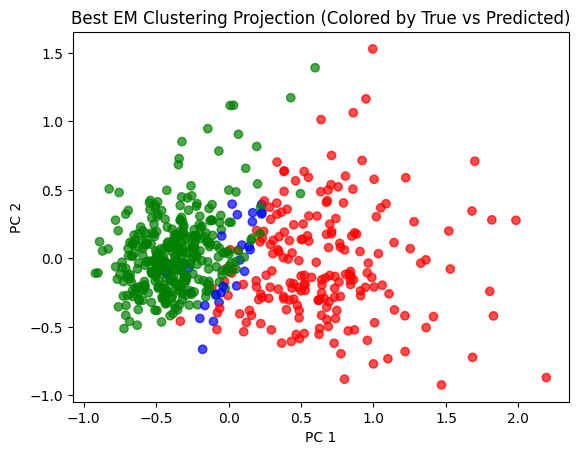

In [6]:
k = 2   # specify k
epsi = 1e-6    # convergence value
n_runs = 10  # number of times to run EM

# We will track the best_nmi and the approximation's attributes

best_nmi = -1   
best_means, best_cov, best_P, best_W = None, None, None, None
best_cluster_assignments = None

# Gather true labels
label_map = {'M': 1, 'B': 0}
true_labels = np.array([label_map[x] for x in diagnosisData])

# We perform n_runs of calculating the expectation maximization, and recording the NMI, tracking if it's our new maximum 
for run in range(n_runs):
    means, cov, P, W = ExpectationMaximization(scaledDataMatrix, k, epsi)
    cluster_assignments = np.argmax(W, axis=0)
    nmi_score = normalized_mutual_info_score(true_labels, cluster_assignments)
    
    print(f"Run {run + 1}: NMI = {nmi_score:.4f}")
    
    if nmi_score > best_nmi:
        best_nmi = nmi_score
        best_means, best_cov, best_P, best_W = means, cov, P, W
        best_cluster_assignments = cluster_assignments

# Now we have our best clustering

#Print the best cluster means
print("\n\nOutputs for best performing clustering")
print("\nCluster Means:")
print("\nCluster 1 Mean:")
print(best_means[0])
print("\nCluster 2 Mean:")
print(best_means[1])

#Print the best cluster covariances
print("\nCluster Covariances:")
for i in range(k):
    print(f"\nCluster {i+1}:")
    print(best_cov[i])

# Print the best cluster sizes
cluster_sizes = np.array([np.sum(best_cluster_assignments == i) for i in range(k)])
print(f"\nCluster sizes: {cluster_sizes}")

# Print the best nmi
print("\nNMI:", best_nmi)

# Use PCA to project our data into 2-dimensions
pca = PCA(n_components=2)
projected_data = pca.fit_transform(scaledDataMatrix)  

# Determine if we need to swap cluster labels
cm = confusion_matrix(true_labels, best_cluster_assignments)

# If more points match by swapping clusters, then swap
if cm[0, 0] + cm[1, 1] < cm[0, 1] + cm[1, 0]:
    best_cluster_assignments = 1 - best_cluster_assignments  # swap 0 to 1
    
# Create color map based on cluster and true label matches
colors = []
for i in range(len(true_labels)):
    if true_labels[i] == 1 and best_cluster_assignments[i] == 1:  # malignant match
        colors.append('red')
    elif true_labels[i] == 0 and best_cluster_assignments[i] == 0:  # benign match
        colors.append('green')
    else:  # mismatch
        colors.append('blue')

# Create plot based on projections
plt.figure()
plt.scatter(projected_data[:, 0], projected_data[:, 1], c=colors, alpha = 0.7)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('Best EM Clustering Projection (Colored by True vs Predicted)')
plt.show()